# Projeto 2: Regressão com Regularização (Lasso/Ridge)

* Tema: Precificação de Veículos Usados
* Dataset: Used Car Price Prediction https://www.kaggle.com/datasets/avikasliwal/used-cars-price-prediction
* Desafio Principal: Prever o preço de revenda lidando com múltiplas variáveis categóricas (marca, modelo).
* Conceitos que preciso dominar: One-Hot Encoding, Multicolinearidade, Overfitting vs. Underfitting, e Regularização L1/L2.

## Passo 1 -Visões iniciais

In [1]:
import pandas as pd

In [3]:
# Carrega o dataset
df = pd.read_csv('train-data.csv')

In [4]:
# Visualiza as primeiras linhas
print(df.head())

   Unnamed: 0                              Name    Location  Year  \
0           0            Maruti Wagon R LXI CNG      Mumbai  2010   
1           1  Hyundai Creta 1.6 CRDi SX Option        Pune  2015   
2           2                      Honda Jazz V     Chennai  2011   
3           3                 Maruti Ertiga VDI     Chennai  2012   
4           4   Audi A4 New 2.0 TDI Multitronic  Coimbatore  2013   

   Kilometers_Driven Fuel_Type Transmission Owner_Type     Mileage   Engine  \
0              72000       CNG       Manual      First  26.6 km/kg   998 CC   
1              41000    Diesel       Manual      First  19.67 kmpl  1582 CC   
2              46000    Petrol       Manual      First   18.2 kmpl  1199 CC   
3              87000    Diesel       Manual      First  20.77 kmpl  1248 CC   
4              40670    Diesel    Automatic     Second   15.2 kmpl  1968 CC   

       Power  Seats  New_Price  Price  
0  58.16 bhp    5.0        NaN   1.75  
1  126.2 bhp    5.0        NaN

In [5]:
# Dimensões do dataset: (linhas, colunas)
print(f"\nDimensões: {df.shape}")


Dimensões: (6019, 14)


In [6]:
# Informações gerais: tipos de dado e contagem de não-nulos por coluna
print("\nInformações gerais:")
df.info()


Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         6019 non-null   int64  
 1   Name               6019 non-null   object 
 2   Location           6019 non-null   object 
 3   Year               6019 non-null   int64  
 4   Kilometers_Driven  6019 non-null   int64  
 5   Fuel_Type          6019 non-null   object 
 6   Transmission       6019 non-null   object 
 7   Owner_Type         6019 non-null   object 
 8   Mileage            6017 non-null   object 
 9   Engine             5983 non-null   object 
 10  Power              5983 non-null   object 
 11  Seats              5977 non-null   float64
 12  New_Price          824 non-null    object 
 13  Price              6019 non-null   float64
dtypes: float64(2), int64(3), object(9)
memory usage: 658.5+ KB


In [7]:
# Estatísticas descritivas das colunas numéricas
print("\nEstatísticas descritivas:")
print(df.describe())


Estatísticas descritivas:
        Unnamed: 0         Year  Kilometers_Driven        Seats        Price
count  6019.000000  6019.000000       6.019000e+03  5977.000000  6019.000000
mean   3009.000000  2013.358199       5.873838e+04     5.278735     9.479468
std    1737.679967     3.269742       9.126884e+04     0.808840    11.187917
min       0.000000  1998.000000       1.710000e+02     0.000000     0.440000
25%    1504.500000  2011.000000       3.400000e+04     5.000000     3.500000
50%    3009.000000  2014.000000       5.300000e+04     5.000000     5.640000
75%    4513.500000  2016.000000       7.300000e+04     5.000000     9.950000
max    6018.000000  2019.000000       6.500000e+06    10.000000   160.000000


## Passo 2: Limpeza básica dos dados

Temos uma série de problemas ao analisar as informações acima:
* Unnamed: 0 ->  é só um índice duplicado que veio do CSV (residual de quando o dataset foi salvo). Não carrega informação nenhuma sobre o carro → Devemos remover.
* New_Price -> só 824 de 6.019 linhas preenchidas (~86% de valores nulos).
Quando uma coluna tem essa taxa de missing, geralmente não vale a pena tentar "salvar" ela (imputar 86% dos dados seria basicamente inventar informação) → Devemos remover.
* Mileage, Engine, Power -> vieram como object (texto) mesmo sendo conceitualmente números. Isso acontece porque o CSV guarda unidade junto: "26.6 kmpl", "998 CC", "58.16 bhp". Precisamos extrair só o número e converter para float, senão o modelo não consegue usar essas colunas.
* Seats -> só 42 valores nulos (6019 - 5977). Como é pouco, não vamos descartar a coluna nem as linhas; vamos imputar (preencher) com a moda (valor mais frequente), já que "número de assentos" é uma variável quase categórica (2, 4, 5, 7...).
* Vamos extrair a marca (Brand) da coluna Name, porque Name tem centenas de valores únicos (ex: "Maruti Swift Dzire VDI", "Hyundai Creta 1.6 CRDi SX Option"). Mais pra frente, no One-Hot Encoding, uma coluna com centenas de categorias únicas geraria centenas de novas colunas (isso se chama alta cardinalidade), o que piora muito o desempenho e a interpretabilidade do modelo

In [8]:
import numpy as np

In [9]:
# Remove colunas inúteis / com excesso de nulos
df = df.drop(columns=['Unnamed: 0', 'New_Price'])

In [10]:
# Extrai a marca (primeira palavra do Name) e remove a coluna Name original
df['Brand'] = df['Name'].apply(lambda x: x.split()[0])
df = df.drop(columns=['Name'])

In [11]:
# Função auxiliar para extrair o número de uma string tipo "26.6 kmpl"
def extrai_numero(valor):
    if pd.isna(valor):
        return np.nan
    try:
        return float(str(valor).split()[0])
    except ValueError:
        return np.nan

df['Mileage'] = df['Mileage'].apply(extrai_numero)
df['Engine'] = df['Engine'].apply(extrai_numero)
df['Power'] = df['Power'].apply(extrai_numero)

In [12]:
# Imputa os nulos remanescentes
df['Mileage'] = df['Mileage'].fillna(df['Mileage'].median())
df['Engine'] = df['Engine'].fillna(df['Engine'].median())
df['Power'] = df['Power'].fillna(df['Power'].median())
df['Seats'] = df['Seats'].fillna(df['Seats'].mode()[0])

In [13]:
# Checagem final: não deve sobrar nenhum nulo
print(df.isnull().sum())
print(f"\nNovas dimensões: {df.shape}")
print(f"\nMarcas únicas: {df['Brand'].nunique()}")
df.info()

Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
Price                0
Brand                0
dtype: int64

Novas dimensões: (6019, 12)

Marcas únicas: 31
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Location           6019 non-null   object 
 1   Year               6019 non-null   int64  
 2   Kilometers_Driven  6019 non-null   int64  
 3   Fuel_Type          6019 non-null   object 
 4   Transmission       6019 non-null   object 
 5   Owner_Type         6019 non-null   object 
 6   Mileage            6019 non-null   float64
 7   Engine             6019 non-null   float64
 8   Power              6019 non-null   float64
 9   Seats              6019

## Entendendo o que é o One-Hot Encoding:

Modelos de regressão (Linear, Ridge, Lasso) são, no fundo, equações matemáticas — eles só sabem multiplicar números por coeficientes. Uma coluna como Fuel_Type com valores "Diesel", "Petrol", "CNG" não significa nada para uma equação.

O One-Hot Encoding resolve isso criando uma coluna binária (0 ou 1) para cada categoria. Por exemplo, Fuel_Type vira 3 colunas: Fuel_Type_Diesel, Fuel_Type_Petrol, Fuel_Type_CNG, cada uma marcando com 1 se aquele carro é daquele tipo, e 0 caso contrário.

Armadilha das Dummy Variables (Dummy Variable Trap): se eu crio uma coluna para cada categoria, elas ficam matematicamente redundantes. Pense em Transmission (Manual/Automatic): se eu sei que Transmission_Manual = 0, já sei com certeza que é automático, não preciso da coluna Transmission_Automatic. 

Manter as duas cria multicolinearidade perfeita entre elas (uma é sempre o "espelho" da outra), o que quebra a matemática por trás da Regressão Linear (a matriz fica singular, sem solução única). Por isso usamos o parâmetro drop_first=True, que descarta a primeira categoria de cada grupo, deixando ela implícita como "categoria de referência".

Isso conecta direto com um dos conceitos que você quer dominar: Multicolinearidade. Com Brand (31 categorias) e Location, vamos gerar bastante colunas novas e é exatamente esse cenário de "muitas variáveis correlacionadas/redundantes" que motiva o uso de Ridge/Lasso mais adiante.

In [14]:
# Colunas categóricas que vamos transformar
colunas_categoricas = ['Location', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Brand']
#Especifica exatamente quais colunas transformar, as numéricas (Year, Kilometers_Driven, etc.) ficam intactas

In [20]:
# One-Hot Encoding com drop_first=True para evitar a dummy variable trap
df_encoded = pd.get_dummies(df, columns=colunas_categoricas, drop_first=True)
# recebe o DataFrame e a lista de colunas categóricas
# devolve o DataFrame com essas colunas substituídas por várias colunas binárias (0/1), uma por categoria

# drop_first=True -> remove a primeira categoria de cada variável (evita a dummy trap explicada acima) 

In [21]:
# Confere o resultado
print(f"Dimensões antes do encoding: {df.shape}")
print(f"Dimensões depois do encoding: {df_encoded.shape}")
print(f"\nPrimeiras colunas geradas:")
print(df_encoded.columns.tolist()[:15])

df_encoded.head()

Dimensões antes do encoding: (6019, 12)
Dimensões depois do encoding: (6019, 55)

Primeiras colunas geradas:
['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Price', 'Location_Bangalore', 'Location_Chennai', 'Location_Coimbatore', 'Location_Delhi', 'Location_Hyderabad', 'Location_Jaipur', 'Location_Kochi', 'Location_Kolkata']


,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price,Location_Bangalore,Location_Chennai,Location_Coimbatore,...,Brand_Mitsubishi,Brand_Nissan,Brand_Porsche,Brand_Renault,Brand_Skoda,Brand_Smart,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Brand_Volvo
0,2010,72000,26.60,998.0,58.16,5.0,1.75,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2015,41000,19.67,1582.0,126.20,5.0,12.50,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2011,46000,18.20,1199.0,88.70,5.0,4.50,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,2012,87000,20.77,1248.0,88.76,7.0,6.00,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,2013,40670,15.20,1968.0,140.80,5.0,17.74,False,False,True,...,False,False,False,False,False,False,False,False,False,False


## Passo 3 - Comparando Regressão Linear Simples

O conceito: Antes de aplicar Ridge/Lasso, precisamos de um baseline, um modelo simples para comparar depois. 

Aqui vamos:

* Separar features (X) e alvo (y): Price é o que queremos prever; todo o resto são as variáveis explicativas.
* Dividir em treino e teste: treinamos o modelo só com uma parte dos dados (ex: 80%) e testamos com dados que ele nunca viu (20%). Isso é fundamental para medir Overfitting: se o modelo vai muito bem no treino mas mal no teste, ele "decorou" os dados de treino em vez de aprender o padrão geral.
* Treinar a Regressão Linear e comparar o erro/R² no treino vs. no teste.

Por que eu espero que isso dê problema? Porque temos 55 colunas, muitas delas (as dummies de Brand) extremamente correlacionadas entre si e com pouca variação (a maioria dos carros é de poucas marcas dominantes, então marcas raras geram colunas quase todas zeradas). Isso é o cenário clássico de multicolinearidade: a Regressão Linear comum, sem nenhuma penalização, tende a gerar coeficientes instáveis e infladas nesse cenário, é exatamente o problema que Ridge e Lasso foram desenhados para resolver.

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [24]:
# 1. Separa features (X) e alvo (y)
X = df_encoded.drop(columns=['Price'])
y = df_encoded['Price']

In [25]:
# 2. Divide em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Embaralha e divide os dados em treino/teste. test_size=0.2 = 20% para teste. random_state=42 fixa a 
# "semente aleatória" para que a divisão seja sempre a mesma toda vez que você rodar (reprodutibilidade)

In [31]:
# 3. Treina a Regressão Linear
lr = LinearRegression()
lr.fit(X_train, y_train) # "Treina" o modelo

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
# 4. Faz previsões no treino e no teste
pred_train = lr.predict(X_train)
pred_test = lr.predict(X_test)

In [33]:
# 5. Avalia com R² (quanto da variação do preço o modelo explica, 0 a 1)
#    e RMSE (erro médio, na mesma unidade do preço - aqui, em lakhs de rupias)
from sklearn.metrics import root_mean_squared_error

print(f"RMSE treino: {root_mean_squared_error(y_train, pred_train):.4f}")
print(f"R² treino: {r2_score(y_train, pred_train):.4f}")

...
print(f"RMSE teste: {root_mean_squared_error(y_test, pred_test):.4f}")
print(f"R² teste: {r2_score(y_test, pred_test):.4f}")


RMSE treino: 5.2076
R² treino: 0.7842
RMSE teste: 7.1917
R² teste: 0.5797


In [30]:
# 6. Olha a magnitude dos coeficientes (é aqui que a multicolinearidade aparece)
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coeficiente': lr.coef_
}).sort_values('Coeficiente', ascending=False)

print("\nTop 5 maiores coeficientes (positivos):")
print(coef_df.head())
print("\nTop 5 menores coeficientes (negativos):")
print(coef_df.tail())


Top 5 maiores coeficientes (positivos):
               Feature  Coeficiente
38   Brand_Lamborghini    63.917072
39          Brand_Land    16.261225
46       Brand_Porsche    15.831696
17  Fuel_Type_Electric    12.536369
36        Brand_Jaguar     8.951994

Top 5 menores coeficientes (negativos):
           Feature  Coeficiente
50      Brand_Tata    -7.081780
28    Brand_Datsun    -7.582825
30     Brand_Force    -8.397047
40  Brand_Mahindra    -8.412136
34     Brand_ISUZU   -11.926158


RMSE: treino = 5.21, teste = 7.19 — o erro no teste é ~38% maior que no treino. Isso é sinal de que o modelo está performando pior em dados que nunca viu, um indício de overfitting.

Essa queda de ~0.20 no R² (de 78% de variação explicada para só 58%) confirma o overfitting: o modelo se ajustou bem demais às particularidades do conjunto de treino (inclusive aos "ruídos" causados por marcas raras como Lamborghini) e perdeu capacidade de generalizar para dados novos. Isso é exatamente o cenário-problema que motiva a Regularização

A tabela de coeficientes já é o "crime perfeito" resolvido: 
* Brand_Lamborghini com coeficiente 63.9. Isso significa, literalmente, que o modelo aprendeu "se é Lamborghini, some +63.9 lakhs ao preço", um ajuste desproporcional. Isso não é o modelo "entendendo" que Lamborghinis são caras de forma equilibrada; é quase certo que existem pouquíssimas linhas de Lamborghini no dataset (talvez 1 ou 2), e o modelo, sem nenhuma penalização, ajustou um coeficiente gigante só para "acertar" aqueles poucos pontos raros, isso é a marca registrada de overfitting em variáveis categóricas esparsas: quanto menos exemplos de uma categoria, mais livre (e instável) o coeficiente fica para se ajustar a eles.
* Repare também que os coeficientes negativos (Brand_Force, Brand_ISUZU, Brand_Mahindra) também são grandes em módulo,
  o mesmo fenômeno, só que "empurrando o preço pra baixo" com força desproporcional.

## Passo 4: Ridge e Lasso — Domando os Coeficientes

1. O conceito

Ridge e Lasso são a Regressão Linear com um "freio de mão" adicionado à matemática. Na Regressão Linear comum, o modelo só tenta minimizar o erro de previsão. Ridge e Lasso adicionam uma penalidade proporcional ao tamanho dos coeficientes, forçando o modelo a ser mais "conservador":
* Ridge (Regularização L2): penaliza a soma dos coeficientes ao quadrado. Isso encolhe todos os coeficientes em direção a zero, de forma suave.
    * Nenhum vira exatamente zero, mas os exagerados (tipo aquele 63.9 do Lamborghini) ficam bem mais comportados.
    * É ótimo para lidar com multicolinearidade, porque distribui o "peso" entre variáveis correlacionadas em vez de deixar uma delas explodir.
* Lasso (Regularização L1): penaliza a soma do valor absoluto dos coeficientes.
    * A diferença crucial é que o Lasso consegue zerar coeficientes completamente.
    * Na prática, ele faz seleção automática de features. Se uma dummy de marca não ajuda muito a prever o preço, o Lasso pode simplesmente eliminá-la do modelo (coeficiente = 0).

Ambos têm um hiperparâmetro chamado alpha (força da penalização): 
* alpha = 0 equivale à Regressão Linear comum (sem regularização).
* Quanto maior o alpha, mais forte o "freio", coeficientes menores, modelo mais simples, mas com risco de underfitting se você exagerar (o modelo fica simples demais e nem consegue capturar os padrões reais).

Como não sabemos de antemão qual alpha é o ideal, vamos usar as versões com validação cruzada (RidgeCV e LassoCV), que testam vários valores de alpha automaticamente e escolhem o melhor.

In [34]:
from sklearn.linear_model import RidgeCV, LassoCV
import numpy as np

In [35]:
# Lista de valores de alpha para testar (escala logarítmica: de 0.01 a 100)
alphas = np.logspace(-2, 2, 50)

Gera 50 valores espaçados em escala logarítmica entre 10⁻² (0.01) e 10² (100) — usamos escala log porque o efeito do alpha é multiplicativo, não linear (a diferença entre alpha=0.01 e 0.1 é proporcionalmente igual à diferença entre 10 e 100)

In [48]:
# --- RIDGE ---
ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train, y_train)

pred_train_ridge = ridge.predict(X_train)
pred_test_ridge = ridge.predict(X_test)

print("=== RIDGE ===")
print(f"Melhor alpha: {ridge.alpha_:.4f}")
print(f"R² treino: {r2_score(y_train, pred_train_ridge):.4f}")
print(f"R² teste: {r2_score(y_test, pred_test_ridge):.4f}")
print(f"RMSE teste: {root_mean_squared_error(y_test, pred_test_ridge):.4f}")

=== RIDGE ===
Melhor alpha: 0.1151
R² treino: 0.7841
R² teste: 0.5784
RMSE teste: 7.2026


Testa cada alpha da lista usando validação cruzada com 5 folds (divide o treino em 5 partes, treina em 4 e valida na 5ª, revezando) e guarda o alpha que deu melhor resultado médio

In [39]:
# --- LASSO ---
lasso = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso.fit(X_train, y_train)

pred_train_lasso = lasso.predict(X_train)
pred_test_lasso = lasso.predict(X_test)

print("\n=== LASSO ===")
print(f"Melhor alpha: {lasso.alpha_:.4f}")
print(f"R² treino: {r2_score(y_train, pred_train_lasso):.4f}")
print(f"R² teste: {r2_score(y_test, pred_test_lasso):.4f}")
print(f"RMSE teste: {root_mean_squared_error(y_test, pred_test_lasso):.4f}")


=== LASSO ===
Melhor alpha: 0.0100
R² treino: 0.7769
R² teste: 0.5628
RMSE teste: 7.3351


Mesma ideia do RidgeCV, mas para Lasso. O max_iter alto é necessário porque o algoritmo de otimização do Lasso (coordinate descent) às vezes precisa de mais iterações para convergir, especialmente com muitas features

In [47]:
# --- COMPARAÇÃO DE COEFICIENTES ---
coef_comparacao = pd.DataFrame({
    'Feature': X.columns,
    'Linear': lr.coef_,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_
})

print("\nComparação para as marcas que antes tinham coeficientes extremos:")
marcas_interesse = ['Brand_Lamborghini', 'Brand_ISUZU', 'Brand_Mahindra']
print(coef_comparacao[coef_comparacao['Feature'].isin(marcas_interesse)])

print(f"\nQuantos coeficientes o Lasso zerou: {(lasso.coef_ == 0).sum()} de {len(lasso.coef_)}")
# Conta quantos coeficientes o Lasso zerou completamente
# é a evidência prática da "seleção de features" que só o Lasso faz


Comparação para as marcas que antes tinham coeficientes extremos:
              Feature     Linear      Ridge      Lasso
34        Brand_ISUZU -11.926158 -11.055678  -0.000000
38  Brand_Lamborghini  63.917072  57.014997  13.710057
40     Brand_Mahindra  -8.412136  -8.110912  -2.444778

Quantos coeficientes o Lasso zerou: 17 de 54


#### Ridge e Lasso não melhoraram... na verdade, pioraram ligeiramente. Isso pode parecer que "a regularização não funcionou"

Por que isso aconteceu?

Ridge e Lasso penalizam a magnitude dos coeficientes, mas isso só é justo se todas as features estiverem na mesma escala. Olha a diferença brutal de escala no seu dataset:
* Kilometers_Driven: varia de milhares a ~100.000+
* Year: varia entre ~2000 e 2019
* Colunas dummy (Brand_X, Fuel_Type_Y): variam só entre 0 e 1

O problema é que a penalização de Ridge/Lasso trata "coeficiente grande" como "coeficiente grande", sem saber que esse tamanho é só um artefato de escala.
* Ela acaba punindo desproporcionalmente as variáveis com escala pequena (como as dummies) e mal toca nas de escala grande.
    * Isso explica por que a regularização não teve força suficiente: o alpha ideal para "consertar" as dummies seria alto demais e prejudicaria as variáveis numéricas.

A solução padrão: padronizar (standardize) todas as features antes de aplicar Ridge/Lasso, colocando todas na mesma escala (média 0, desvio padrão 1).

## Passo 4.2: Padronização (StandardScaler) + Ridge/Lasso corrigidos

StandardScaler transforma cada coluna numérica assim: 
(valor - média) / desvio_padrão. 

Depois disso, toda feature passa a ter média 0 e desvio padrão 1 — todas "competem" na mesma escala pela penalização. Isso não afeta a Regressão Linear pura (ela é invariante à escala), mas é crucial para Ridge e Lasso.

Importante: o StandardScaler deve ser ajustado (fit) somente com os dados de treino, e depois aplicado (transform) tanto no treino quanto no teste. 
* Se você "olhar" os dados de teste durante o fit do scaler, está vazando informação do teste para o treino (chamado de data leakage), isso inflaria artificialmente sua performance de forma enganosa.

In [51]:
from sklearn.preprocessing import StandardScaler

In [53]:
# 1. Cria e ajusta o scaler SÓ com dados de treino
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # usa a média/desvio do treino, não recalcula

In [54]:
# 2. Amplia a grade de alphas, já que suspeitamos que o ideal é bem pequeno
alphas = np.logspace(-3, 3, 100)

In [55]:
# --- RIDGE (com dados padronizados) ---
ridge_scaled = RidgeCV(alphas=alphas, cv=5)
ridge_scaled.fit(X_train_scaled, y_train)

pred_test_ridge_scaled = ridge_scaled.predict(X_test_scaled)

print("=== RIDGE (padronizado) ===")
print(f"Melhor alpha: {ridge_scaled.alpha_:.4f}")
print(f"R² treino: {r2_score(y_train, ridge_scaled.predict(X_train_scaled)):.4f}")
print(f"R² teste: {r2_score(y_test, pred_test_ridge_scaled):.4f}")
print(f"RMSE teste: {root_mean_squared_error(y_test, pred_test_ridge_scaled):.4f}")

=== RIDGE (padronizado) ===
Melhor alpha: 61.3591
R² treino: 0.7841
R² teste: 0.5746
RMSE teste: 7.2352


In [56]:
# --- LASSO (com dados padronizados) ---
lasso_scaled = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_scaled.fit(X_train_scaled, y_train)

pred_test_lasso_scaled = lasso_scaled.predict(X_test_scaled)

print("\n=== LASSO (padronizado) ===")
print(f"Melhor alpha: {lasso_scaled.alpha_:.4f}")
print(f"R² treino: {r2_score(y_train, lasso_scaled.predict(X_train_scaled)):.4f}")
print(f"R² teste: {r2_score(y_test, pred_test_lasso_scaled):.4f}")
print(f"RMSE teste: {root_mean_squared_error(y_test, pred_test_lasso_scaled):.4f}")

print(f"\nCoeficientes zerados pelo Lasso: {(lasso_scaled.coef_ == 0).sum()} de {len(lasso_scaled.coef_)}")


=== LASSO (padronizado) ===
Melhor alpha: 0.0187
R² treino: 0.7840
R² teste: 0.5918
RMSE teste: 7.0876

Coeficientes zerados pelo Lasso: 5 de 54


### Conclusões

* O Lasso foi o único que realmente melhorou, ainda que modestamente (+0.012 no R², -0.10 no RMSE em relação ao Linear).
    * Isso faz sentido: como o Lasso consegue zerar coeficientes (5 features zeradas aqui), ele está removendo ruído puro do modelo, provavelmente dummies de marcas raras que, como vimos, geravam coeficientes instáveis sem agregar poder preditivo real.

* O Ridge não ajudou neste caso, ficou até marginalmente pior que o Linear.
    * Isso não significa que "Ridge é ruim", significa que o problema aqui não era de coeficientes moderadamente grandes e correlacionados (que é o forte do Ridge), e sim de algumas poucas variáveis puramente ruidosas (que é o forte do Lasso, por eliminar via seleção).
    * Ou seja: a estrutura do seu problema tinha mais cara de "preciso descartar variáveis inúteis" do que "preciso distribuir peso entre variáveis correlacionadas".

* O ganho geral foi pequeno (R² foi de ~0.58 para ~0.59).
    * Isso é um sinal importante e honesto: o teto de performance aqui provavelmente não está mais na regularização.
    * Regularização resolve overfitting causado por complexidade excessiva/multicolinearidade, mas não resolve limitações de representação, por exemplo:
        * A relação entre Price e as features pode não ser puramente linear (ex: depreciação de carro tende a ser exponencial com Year/Kilometers_Driven, não linear).
        * Price provavelmente tem distribuição bem assimétrica (poucos carros muito caros puxando a cauda) — nesses casos, aplicar log(Price) antes de modelar costuma ajudar bastante modelos lineares.

## Visualizações de gráficos

In [58]:
import matplotlib.pyplot as plt

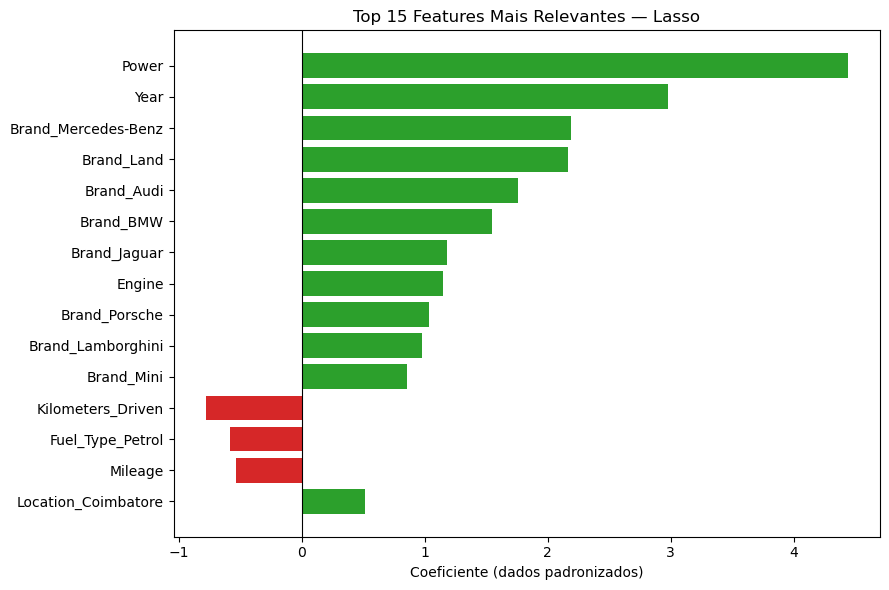

In [59]:
# ===== GRÁFICO 1: Coeficientes do Lasso (padronizado) =====
coef_lasso_df = pd.DataFrame({
    'Feature': X.columns,
    'Coeficiente': lasso_scaled.coef_
})
# Pega as 15 features com maior impacto em módulo (positivo ou negativo)
top_coef = coef_lasso_df.reindex(
    coef_lasso_df['Coeficiente'].abs().sort_values(ascending=False).index
).head(15)

plt.figure(figsize=(9, 6))
colors = ['#d62728' if c < 0 else '#2ca02c' for c in top_coef['Coeficiente']]
plt.barh(top_coef['Feature'], top_coef['Coeficiente'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente (dados padronizados)')
plt.title('Top 15 Features Mais Relevantes — Lasso')
plt.gca().invert_yaxis()  # maior impacto no topo
plt.tight_layout()
plt.show()

* Power e Year são as variáveis mais fortes e positivas -> carros mais potentes e mais novos custam mais.
* Marcas de luxo (Mercedes-Benz, Land [Rover], Audi, BMW, Jaguar, Porsche, Lamborghini, Mini) têm coeficientes positivos: o modelo aprendeu a associar essas marcas a preços mais altos, mesmo já controlando por potência/ano.
* Kilometers_Driven, Fuel_Type_Petrol e Mileage são negativos: mais km rodado deprecia o carro.
    * Mileage aqui é "km por litro" (consumo), então carros mais econômicos tendem a ser os populares/baratos, enquanto carros de luxo (motores grandes, menos econômicos) custam mais

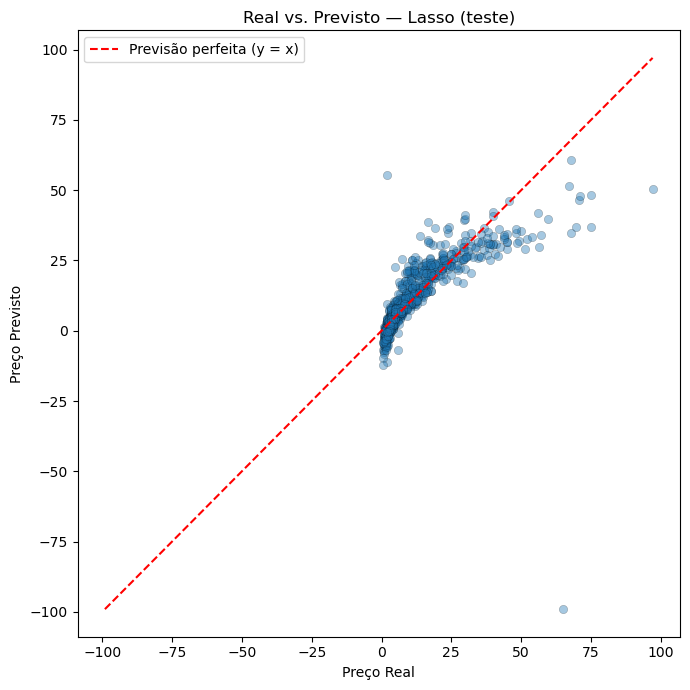

In [60]:
# ===== GRÁFICO 2: Real vs. Previsto (Lasso, teste) =====
plt.figure(figsize=(7, 7))
plt.scatter(y_test, pred_test_lasso_scaled, alpha=0.4, edgecolor='k', linewidth=0.3)
lims = [min(y_test.min(), pred_test_lasso_scaled.min()),
        max(y_test.max(), pred_test_lasso_scaled.max())]
plt.plot(lims, lims, 'r--', label='Previsão perfeita (y = x)')
plt.xlabel('Preço Real')
plt.ylabel('Preço Previsto')
plt.title('Real vs. Previsto — Lasso (teste)')
plt.legend()
plt.tight_layout()
plt.show()

Aqui vejo dois problemas, um esperado e um novo:

* O esperado: para preços mais altos (acima de ~30-40), a nuvem de pontos começa a se afastar da linha vermelha, ficando abaixo dela, ou seja, o modelo tende a subestimar carros caros.
    * Confirma exatamente a suspeita de heterocedasticidade.
* O inesperado (e mais grave): tem um ponto solitário lá embaixo, perto de Real ≈ 65, Previsto ≈ -100.
    * Isso é um problema sério -> um preço previsto negativo, o que é fisicamente impossível (não existe carro com preço de revenda negativo).
    * Isso é sinal de que, para esse carro específico, a combinação de variáveis (provavelmente uma marca rara + alguma outra característica atípica) fez o modelo linear extrapolar violentamente para fora da faixa plausível.

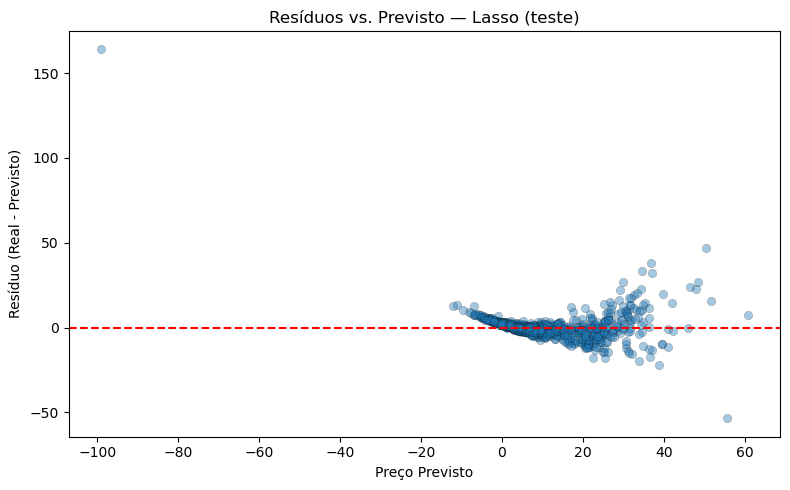

In [61]:
# ===== GRÁFICO 3: Resíduos (erro) vs. Previsto =====
residuos = y_test - pred_test_lasso_scaled

plt.figure(figsize=(8, 5))
plt.scatter(pred_test_lasso_scaled, residuos, alpha=0.4, edgecolor='k', linewidth=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Preço Previsto')
plt.ylabel('Resíduo (Real - Previsto)')
plt.title('Resíduos vs. Previsto — Lasso (teste)')
plt.tight_layout()
plt.show()

* O formato de "funil" está bem visível: perto de previsto = 0, os resíduos ficam bem colados na linha vermelha (erro pequeno e consistente).
* Conforme o preço previsto sobe, os pontos se espalham cada vez mais (erro cresce em magnitude E variabilidade).
    * Isso é heterocedasticidade confirmada visualmente -> o modelo é bom para carros baratos/médios e ruim (e imprevisível) para carros caros.

O mesmo outlier extremo aparece isolado no canto superior esquerdo (previsto ≈ -100, resíduo ≈ +160) — ele "puxa" bastante a escala do gráfico inteiro, comprimindo visualmente todos os outros pontos. Vale a pena identificar esse carro específico depois.

#### A relação entre as features e Price provavelmente não é linear, e Price tem uma distribuição assimétrica (poucos carros muito caros). 
#### Um modelo linear "estica" a reta para tentar dar conta dos dois extremos (carros baratos e carros de luxo) e acaba errando mais nas pontas, especialmente nos casos raros, onde pode até extrapolar para valores absurdos como preço negativo.

## Investigando os outliers

In [63]:
# Recalcula os resíduos com o índice preservado (y_test já é uma Series com índice original)
residuos_series = y_test - pred_test_lasso_scaled

In [64]:
# Encontra o índice do maior resíduo em módulo (o outlier mais extremo)
idx_outlier = residuos_series.abs().sort_values(ascending=False).index[0]

print(f"Índice do outlier: {idx_outlier}")
print(f"Preço real: {y_test.loc[idx_outlier]:.2f}")
print(f"Preço previsto: {pred_test_lasso_scaled[y_test.index.get_loc(idx_outlier)]:.2f}")
print(f"Resíduo: {residuos_series.loc[idx_outlier]:.2f}")

print("\n--- Dados originais (limpos) desse carro ---")
print(df.loc[idx_outlier])

print("\n--- Comparação com a mediana do dataset (para achar o que é atípico) ---")
comparacao = pd.DataFrame({
    'Carro Outlier': df.loc[idx_outlier],
    'Mediana Geral': df.median(numeric_only=True)
})
print(comparacao)

Índice do outlier: 2328
Preço real: 65.00
Preço previsto: -99.05
Resíduo: 164.05

--- Dados originais (limpos) desse carro ---
Location               Chennai
Year                      2017
Kilometers_Driven      6500000
Fuel_Type               Diesel
Transmission         Automatic
Owner_Type               First
Mileage                  15.97
Engine                  2993.0
Power                    258.0
Seats                      5.0
Price                     65.0
Brand                      BMW
Name: 2328, dtype: object

--- Comparação com a mediana do dataset (para achar o que é atípico) ---
                  Carro Outlier  Mediana Geral
Brand                       BMW            NaN
Engine                   2993.0        1493.00
Fuel_Type                Diesel            NaN
Kilometers_Driven       6500000       53000.00
Location                Chennai            NaN
Mileage                   15.97          18.15
Owner_Type                First            NaN
Power                    

In [65]:
# Bônus: quantos carros da MESMA marca existem no dataset inteiro?
marca_outlier = df.loc[idx_outlier, 'Brand']
print(f"\nQuantos carros da marca '{marca_outlier}' existem no dataset: {(df['Brand'] == marca_outlier).sum()}")


Quantos carros da marca 'BMW' existem no dataset: 267


In [66]:
# Verifica quantos carros têm Kilometers_Driven acima de um limite plausível (ex: 500.000 km)
print(df[df['Kilometers_Driven'] > 500000][['Brand', 'Year', 'Kilometers_Driven', 'Price']])

           Brand  Year  Kilometers_Driven  Price
340        Skoda  2013             775000    7.5
358      Hyundai  2009             620000    2.7
1860  Volkswagen  2013             720000    5.9
2328         BMW  2017            6500000   65.0


In [67]:
# 1. Remove apenas o outlier fisicamente implausível (erro de dado)
df_clean = df[df['Kilometers_Driven'] < 1_000_000].copy()

print(f"Linhas antes: {len(df)}, depois: {len(df_clean)}")

# 2. Refaz o One-Hot Encoding a partir do df limpo
df_clean_encoded = pd.get_dummies(df_clean, columns=colunas_categoricas, drop_first=True)

# 3. Refaz o split
X2 = df_clean_encoded.drop(columns=['Price'])
y2 = df_clean_encoded['Price']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

# 4. Refaz a padronização (fit só no novo treino)
scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

# 5. Retreina o Lasso com validação cruzada
lasso2 = LassoCV(alphas=np.logspace(-3, 3, 100), cv=5, max_iter=10000)
lasso2.fit(X2_train_scaled, y2_train)

pred2_train = lasso2.predict(X2_train_scaled)
pred2_test = lasso2.predict(X2_test_scaled)

print(f"\nMelhor alpha: {lasso2.alpha_:.4f}")
print(f"R² treino: {r2_score(y2_train, pred2_train):.4f}")
print(f"R² teste: {r2_score(y2_test, pred2_test):.4f}")
print(f"RMSE teste: {root_mean_squared_error(y2_test, pred2_test):.4f}")

Linhas antes: 6019, depois: 6018

Melhor alpha: 0.0142
R² treino: 0.7927
R² teste: 0.7328
RMSE teste: 5.9693


Uma única linha removida (de 6019) fez o R² de teste saltar de ~0.59 para 0.73. Um ganho de +0.14, muito maior do que qualquer coisa que Ridge ou Lasso conseguiram sozinhos ao "domar" coeficientes. Isso é a lição mais valiosa do projeto inteiro, e vale a pena você guardar como princípio geral:

Regularização protege contra overfitting causado pela complexidade do modelo (muitas features, multicolinearidade). Ela não protege contra dados errados. Um único valor absurdo (6.5 milhões de km) tinha poder suficiente para distorcer os coeficientes do modelo inteiro e inflar o erro de teste — porque a Regressão Linear (e suas variantes regularizadas) usam erro quadrático, que penaliza desproporcionalmente pontos muito distantes. Um outlier extremo pesa como dezenas de pontos "normais" na função de custo.

### Revendo os gráficos

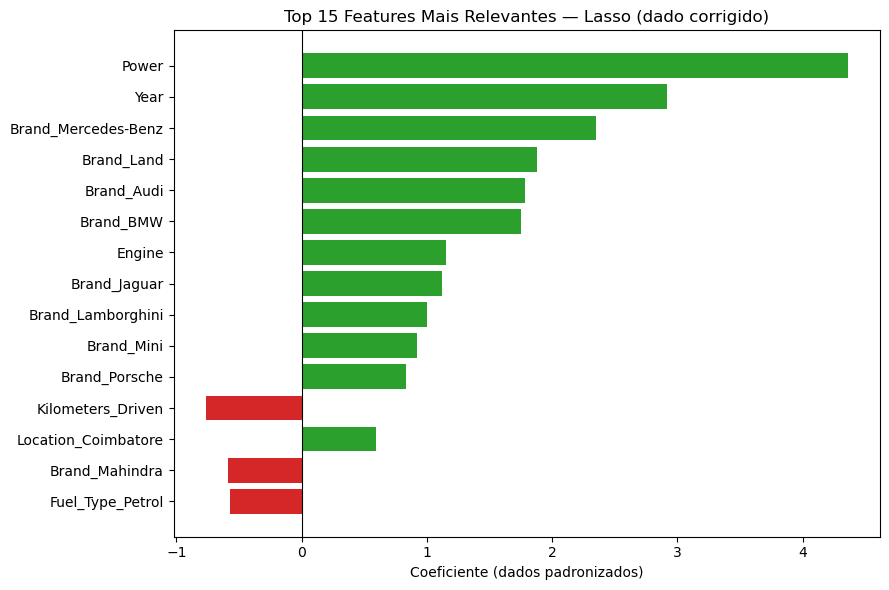

In [71]:
# ===== GRÁFICO 1: Coeficientes do Lasso (modelo limpo) =====
coef_lasso2_df = pd.DataFrame({
    'Feature': X2.columns,
    'Coeficiente': lasso2.coef_
})
top_coef2 = coef_lasso2_df.reindex(
    coef_lasso2_df['Coeficiente'].abs().sort_values(ascending=False).index
).head(15)

plt.figure(figsize=(9, 6))
colors = ['#d62728' if c < 0 else '#2ca02c' for c in top_coef2['Coeficiente']]
plt.barh(top_coef2['Feature'], top_coef2['Coeficiente'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente (dados padronizados)')
plt.title('Top 15 Features Mais Relevantes — Lasso (dado corrigido)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

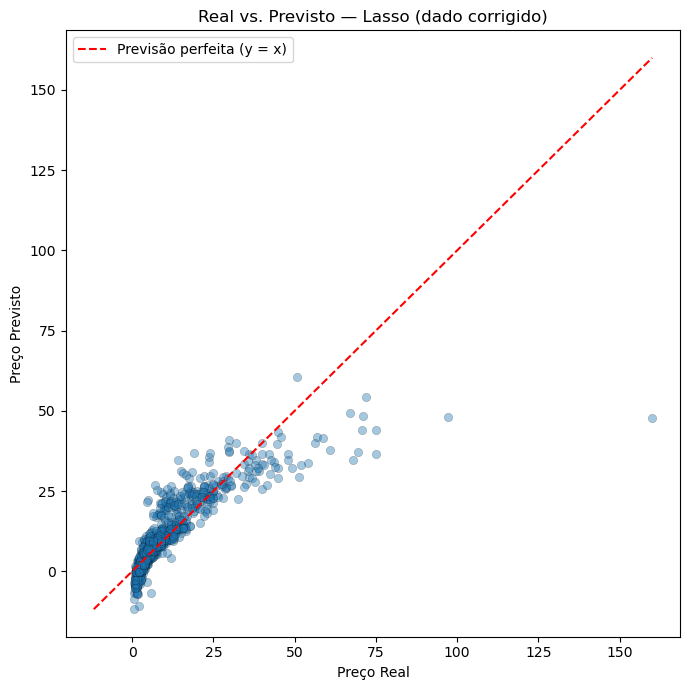

In [72]:
# ===== GRÁFICO 2: Real vs. Previsto (modelo limpo) =====
plt.figure(figsize=(7, 7))
plt.scatter(y2_test, pred2_test, alpha=0.4, edgecolor='k', linewidth=0.3)
lims = [min(y2_test.min(), pred2_test.min()),
        max(y2_test.max(), pred2_test.max())]
plt.plot(lims, lims, 'r--', label='Previsão perfeita (y = x)')
plt.xlabel('Preço Real')
plt.ylabel('Preço Previsto')
plt.title('Real vs. Previsto — Lasso (dado corrigido)')
plt.legend()
plt.tight_layout()
plt.show()


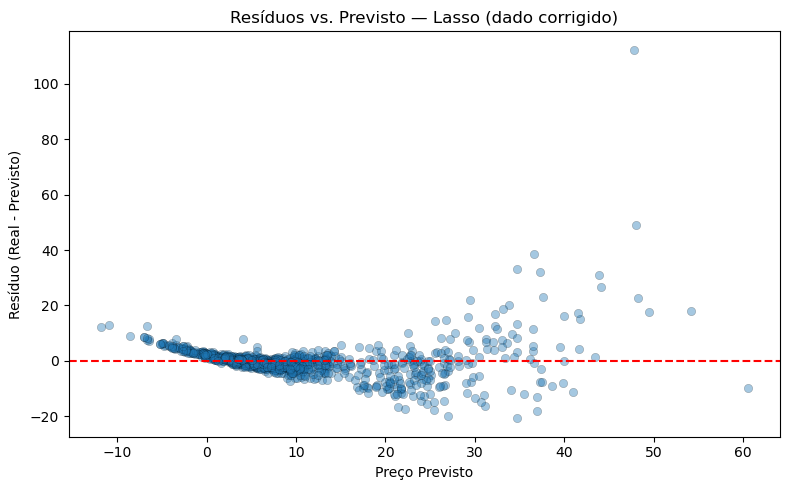

In [73]:
# ===== GRÁFICO 3: Resíduos vs. Previsto (modelo limpo) =====
residuos2 = y2_test - pred2_test

plt.figure(figsize=(8, 5))
plt.scatter(pred2_test, residuos2, alpha=0.4, edgecolor='k', linewidth=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Preço Previsto')
plt.ylabel('Resíduo (Real - Previsto)')
plt.title('Resíduos vs. Previsto — Lasso (dado corrigido)')
plt.tight_layout()
plt.show()

In [74]:
idx_novo_outlier = (y2_test - pred2_test).abs().sort_values(ascending=False).index[0]
print(df_clean.loc[idx_novo_outlier])

Location             Hyderabad
Year                      2017
Kilometers_Driven        25000
Fuel_Type               Diesel
Transmission         Automatic
Owner_Type               First
Mileage                  13.33
Engine                  2993.0
Power                    255.0
Seats                      5.0
Price                    160.0
Brand                     Land
Name: 4079, dtype: object


## Conclusão

Aprendizados-chave
* One-Hot Encoding com drop_first=True é essencial, mas variáveis categóricas de alta cardinalidade (como Brand, com 31 categorias) geram dummies esparsas que amplificam multicolinearidade, evidenciada por coeficientes explosivos na Regressão Linear pura (ex: +63.9 para Brand_Lamborghini).
* Regularização sem padronização é ineficaz.
    * Ridge e Lasso penalizam a magnitude dos coeficientes, mas isso só é justo quando todas as features estão na mesma escala.
    * Sem StandardScaler, o alpha ideal encontrado por validação cruzada ficou preso na borda da grade de busca — sinal de que a regularização não estava tendo efeito real.
* Ridge e Lasso resolvem problemas diferentes.
    * Neste dataset, o Lasso superou o Ridge porque o problema era mais de "variáveis irrelevantes que precisam ser descartadas" (Lasso zera coeficientes) do que de "variáveis correlacionadas que precisam dividir peso" (forte do Ridge).
* A maior fonte de erro não era o modelo, era a qualidade do dado.
    * Um único registro com valor implausível (6,5 milhões de km rodados, provável erro de digitação) distorcia tanto o treino quanto a padronização, derrubando o R² de teste.
    * Removê-lo gerou um ganho de performance (+0.14 no R²) muito maior do que qualquer ajuste de regularização conseguiu sozinho.
* Overfitting tem duas causas distintas, e é preciso saber diferenciá-las:
    * complexidade excessiva do modelo (que regularização resolve) vs. contaminação por dados errados (que só limpeza resolve).
        * Aplicar a ferramenta certa para o problema certo evita "forçar" a regularização a compensar um problema que ela não foi desenhada para resolver.
* Limitação identificada, não resolvida: os gráficos de resíduos mostraram heterocedasticidade persistente.
    * O modelo erra mais (e de forma mais dispersa) em carros caros, refletindo a distribuição assimétrica do preço e possível não-linearidade nas relações.
    * Transformação logarítmica de Price foi identificada como próximo passo natural, mas fica como investigação futura.